# Bike Sharing Demand Predictions

Bike sharing systems are widely used in urban environments and provide valuable data for understanding how factors such as weather, time, and seasonality influence ridership. Predicting bike demand can help city planners and transportation services better allocate resources and optimize availability.

In this project, the goal is to build machine learning models capable of predicting the number of bike rentals (cnt) based on time, weather, and seasonal features.

The analysis follows a standard data science workflow:
1. Data exploration and feature analysis
2. Feature engineering and preprocessing
3. Exploratory data analysis (EDA)
4. Model training using multiple regression algorithms
5. Model comparison and evaluation
6. Interpretation through feature importance and residual analysis

Several models are evaluated, including:
- Linear Regression
- Decision Tree Regressor
- Random Forest Regressor
- Gradient Boosting Regressor
- XGBoost Regressor

The goal is to identify which modelling approach best captures the underlying patterns in bike demand.

## Imports

This section imports the Python libraries used throughout the analysis. The project relies primarily on the pandas and NumPy libraries for data manipulation, matplotlib and seaborn for visualization, and scikit-learn for machine learning pipelines and model evaluation. The XGBoost library is also included as an advanced gradient boosting method commonly used in predictive modeling.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import cross_val_score, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.metrics import r2_score, root_mean_squared_error
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer

from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor

%matplotlib inline
sns.set_style("whitegrid")

## Load Data

In [2]:
df = pd.read_csv("../data/hour.csv")
df_original =  df.copy()

## Data Overview

Before performing any modeling, it is important to understand the structure and contents of the dataset. This section displays the first few rows of the data, inspects the data types of each column, and provides summary statistics for all numerical variables. These steps help identify potential data quality issues and provide an initial understanding of the features available for modeling.

In [3]:
df.head()

,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17379 entries, 0 to 17378
Data columns (total 17 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     17379 non-null  int64  
 1   dteday      17379 non-null  object 
 2   season      17379 non-null  int64  
 3   yr          17379 non-null  int64  
 4   mnth        17379 non-null  int64  
 5   hr          17379 non-null  int64  
 6   holiday     17379 non-null  int64  
 7   weekday     17379 non-null  int64  
 8   workingday  17379 non-null  int64  
 9   weathersit  17379 non-null  int64  
 10  temp        17379 non-null  float64
 11  atemp       17379 non-null  float64
 12  hum         17379 non-null  float64
 13  windspeed   17379 non-null  float64
 14  casual      17379 non-null  int64  
 15  registered  17379 non-null  int64  
 16  cnt         17379 non-null  int64  
dtypes: float64(4), int64(12), object(1)
memory usage: 2.3+ MB


In [5]:
df.describe()

,instant,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.0000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000,17379.000000
mean,8690.0000,2.501640,0.502561,6.537775,11.546752,0.028770,3.003683,0.682721,1.425283,0.496987,0.475775,0.627229,0.190098,35.676218,153.786869,189.463088
std,5017.0295,1.106918,0.500008,3.438776,6.914405,0.167165,2.005771,0.465431,0.639357,0.192556,0.171850,0.192930,0.122340,49.305030,151.357286,181.387599
min,1.0000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.020000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,4345.5000,2.000000,0.000000,4.000000,6.000000,0.000000,1.000000,0.000000,1.000000,0.340000,0.333300,0.480000,0.104500,4.000000,34.000000,40.000000
50%,8690.0000,3.000000,1.000000,7.000000,12.000000,0.000000,3.000000,1.000000,1.000000,0.500000,0.484800,0.630000,0.194000,17.000000,115.000000,142.000000
75%,13034.5000,3.000000,1.000000,10.000000,18.000000,0.000000,5.000000,1.000000,2.000000,0.660000,0.621200,0.780000,0.253700,48.000000,220.000000,281.000000
max,17379.0000,4.000000,1.000000,12.000000,23.000000,1.000000,6.000000,1.000000,4.000000,1.000000,1.000000,1.000000,0.850700,367.000000,886.000000,977.000000


## Feature Analysis/Engineering

This section examines relationships between features and performs initial feature engineering.

First, the correlation between temp and atemp is analyzed. These variables represent actual temperature and perceived temperature, and they are highly correlated. To avoid redundancy and potential multicollinearity, the atemp feature is removed.

Next, the hr variable (hour of day) is transformed using sine and cosine transformations. Since hours follow a cyclical pattern (e.g., hour 23 and hour 0 are close in time), these transformations preserve the cyclical nature of time and allow models to better capture daily demand patterns.

Finally, several columns that are either redundant or could introduce data leakage are removed from the dataset.

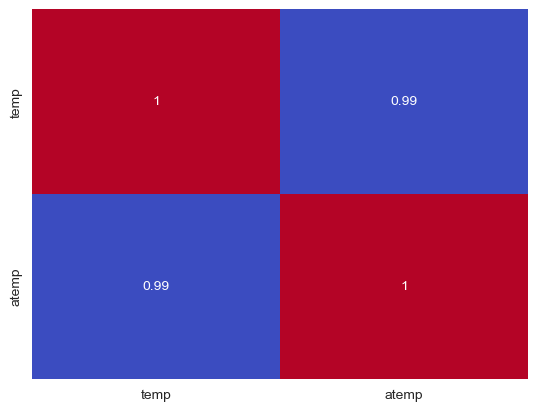

In [6]:
sns.heatmap(df[['temp', 'atemp']].corr(), annot = True, cmap='coolwarm', cbar=False);

In [7]:
df['hr_sin'] = np.sin(2 * np.pi * df['hr']/24)
df['hr_cos'] = np.cos(2 * np.pi * df['hr']/24)

In [8]:
df = df.drop(columns=['hr', 'instant', 'atemp', 'casual', 'registered'])

## Exploratory Data Analysis (EDA)

The analysis begins by examining the distribution of the target variable (cnt) to understand the overall demand pattern. Additional visualizations explore relationships between bike demand and key feature groups, including time-related features, weather conditions, and day-related variables.

These visualizations provide insight into patterns such as peak usage times, seasonal demand changes, and the impact of weather on bike rentals.

### Target Distribution Plot

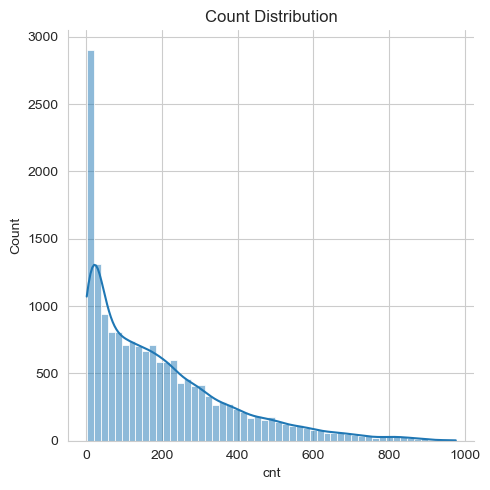

In [9]:
sns.displot(df['cnt'], kde = True)
plt.title('Count Distribution')
plt.tight_layout()

The distribution of the target variable (cnt), which represents the number of bike rentals per hour, appears to be right-skewed. Most observations fall within the lower range of rental counts, while a smaller number of observations show very high demand.

This pattern suggests that during many hours of the day bike usage is relatively moderate, while peak demand periods occur less frequently but can reach much higher rental counts. These peaks are likely associated with commuting hours or periods of favorable weather conditions.

The skewed distribution also indicates that extreme high-demand values exist in the dataset, which may influence model performance and error metrics such as RMSE. Tree-based models are generally well suited for handling such distributions because they can capture nonlinear relationships and interactions between features.

### Time Features vs Count

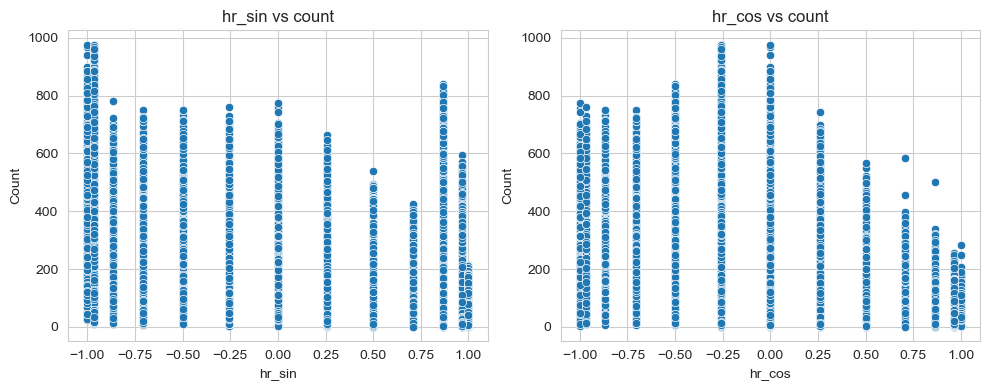

In [10]:
time_features = ['hr_sin', 'hr_cos']

fig, axes = plt.subplots(nrows = 1, ncols = 2, figsize = (10,4))

for i, col in enumerate(time_features):
    sns.scatterplot(data=df, x = col, y = 'cnt', ax = axes[i])
    axes[i].set_title(f'{col} vs count')
    axes[i].set_ylabel('Count')

plt.tight_layout()

<Axes: xlabel='hr', ylabel='cnt'>

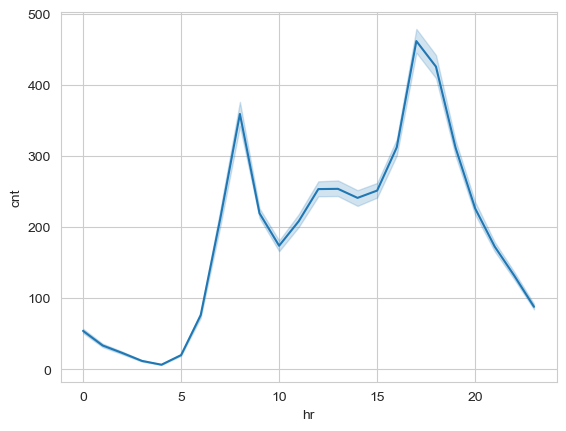

In [11]:
sns.lineplot(data=df_original, x="hr", y="cnt")

The scatter plots show the relationship between the cyclical time features (hr_sin and hr_cos) and the target variable (cnt). These features were created using sine and cosine transformations of the hour variable to capture the cyclical nature of time within a 24-hour day.

Although the relationship does not appear strictly linear, clear patterns can be observed. Certain regions of the sine and cosine values correspond to higher concentrations of bike rentals, which reflects periods of increased demand throughout the day. These patterns likely correspond to commuting hours and other peak usage periods.

Because the relationship between time and bike demand is cyclical and nonlinear, transforming the hour variable using sine and cosine allows machine learning models to better capture daily demand patterns compared to using the raw hour value.

### Weather Features vs Count

In [12]:
temperature_features = ['temp', 'hum', 'windspeed']

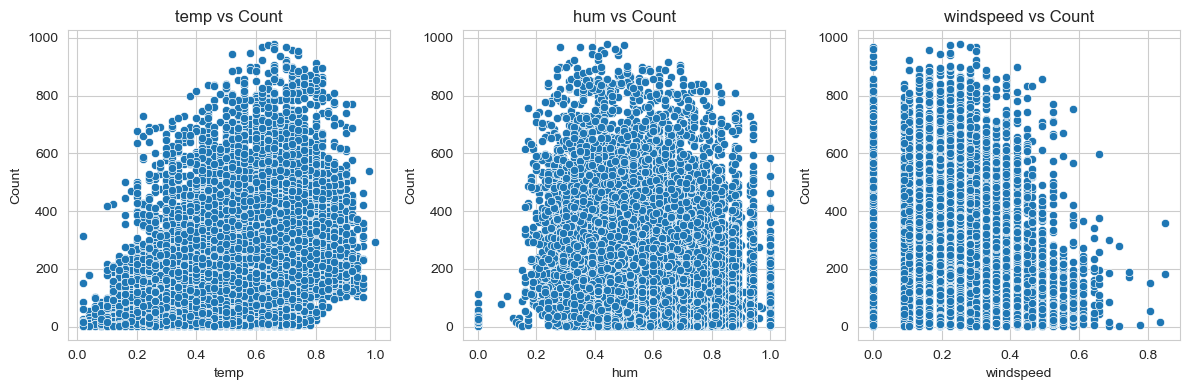

In [13]:
fig, axes = plt.subplots(nrows = 1, ncols =3, figsize = (12,4))

axes=axes.flatten()

for i, col in enumerate(temperature_features):
    sns.scatterplot(data = df, x=col, y = 'cnt', ax = axes[i])
    axes[i].set_title(f'{col} vs Count')
    axes[i].set_ylabel('Count')

plt.tight_layout()

The scatter plots illustrate the relationship between weather-related features (temp, hum, and windspeed) and the number of bike rentals (cnt).

**Temperature** shows the clearest relationship with bike demand. As temperature increases, the number of rentals generally tends to rise, suggesting that warmer weather encourages greater bike usage. This aligns with expectations, as cycling is typically more appealing in comfortable weather conditions.

**Humidity appears** to have a weaker and slightly negative relationship with demand. Higher humidity levels are often associated with lower rental counts, which may reflect less comfortable riding conditions.

**Wind speed** shows little clear linear relationship with bike rentals, although higher wind speeds tend to correspond with lower demand.

Overall, these plots suggest that **weather conditions—particularly temperature—play an important role in influencing bike rental activity**, though the relationships are not strictly linear.

### Day Descriptive Features vs Count

In [14]:
day_features = ['season', 'yr', 'mnth', 'holiday', 'weekday', 'workingday']

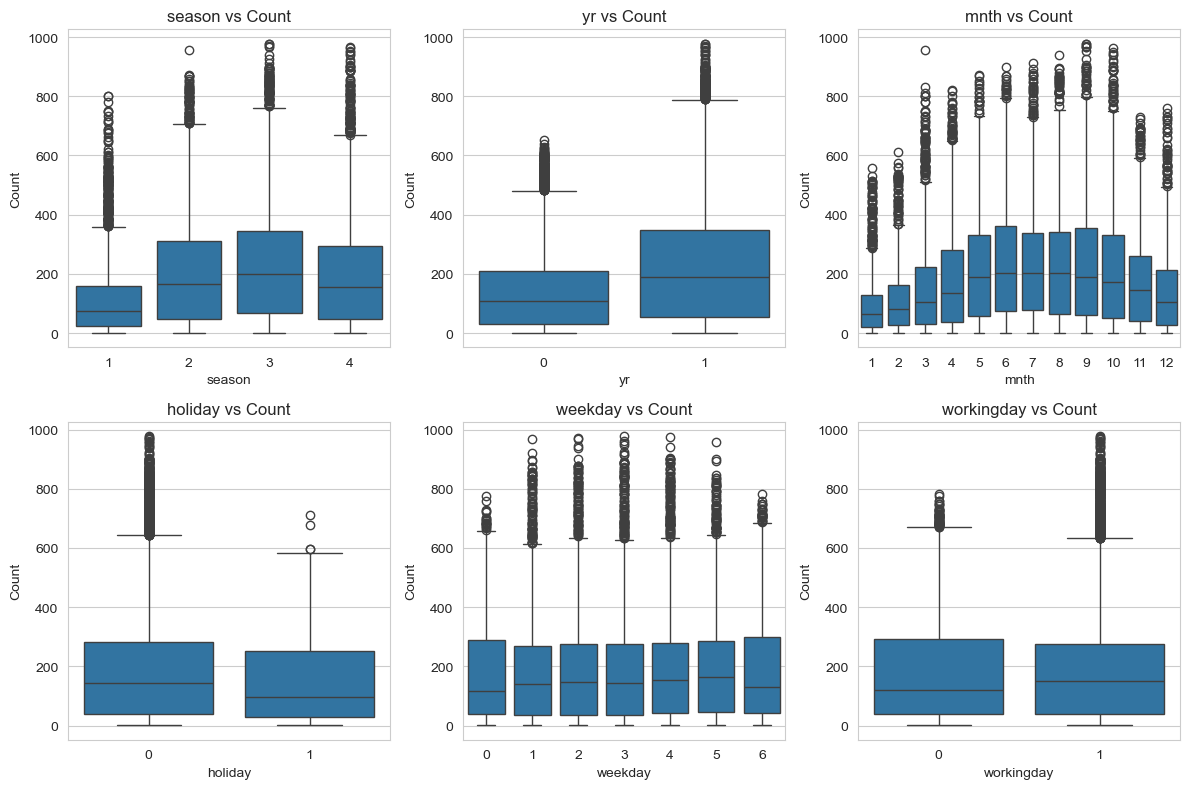

In [15]:
fig, axes = plt.subplots(nrows = 2, ncols = 3, figsize = (12,8))

axes=axes.flatten()

for i, col in enumerate(day_features):
    sns.boxplot(data = df, x = col, y='cnt', ax = axes[i])
    axes[i].set_title(f'{col} vs Count')
    axes[i].set_ylabel('Count')

plt.tight_layout()

The boxplots illustrate how bike rental demand varies across several day-related features, including season, year, month, holidays, weekdays, and working days.

**Seasonal patterns** are clearly visible, with **higher rental counts occurring during warmer seasons**, particularly in summer and fall. This aligns with expectations, as favorable weather conditions encourage outdoor transportation and recreational cycling.

The **year** (yr) variable shows a noticeable increase in demand in the second year of the dataset, suggesting that bike usage grew over time. This may reflect increasing adoption of the bike-sharing system.

**Monthly** trends further highlight seasonal effects. Rental activity tends to increase during the middle months of the year and decline during colder months, reinforcing the strong seasonal influence on bike demand.

**Differences between holidays and non-holidays appear less pronounced**, though holidays tend to show slightly lower median demand. Weekday patterns also suggest moderate variation throughout the week, while working days generally exhibit slightly higher demand, likely due to commuting behavior.

Overall, these patterns indicate that **seasonality and calendar-based factors play an important role in shaping bike rental demand**, particularly through monthly and seasonal trends.

## Feature Correlation

In [16]:
categorical_cols = ['season', 'mnth','weekday','weathersit']
categorical_cols_no_onehot = ['holiday', 'workingday', 'yr']
numerical_cols = ['temp',  'hum', 'windspeed', 'hr_sin', 'hr_cos']

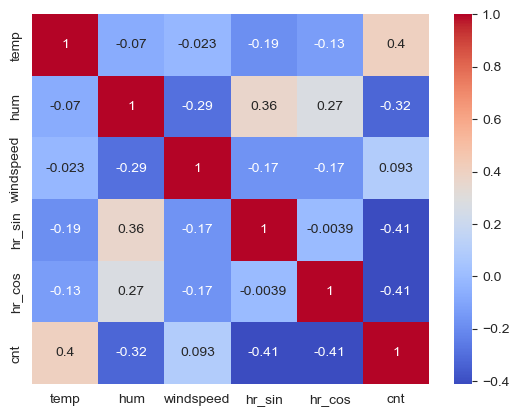

In [17]:
corr = df[numerical_cols + ['cnt']].corr()
sns.heatmap(data = corr, annot = True, cmap = 'coolwarm');

Among the variables examined, **temperature** (temp) **shows the strongest positive correlation with bike demand**, with a correlation of approximately **0.40**. This suggests that higher temperatures are generally associated with increased bike usage.

In contrast, **humidity** (hum) exhibits a **moderate negative correlation with demand (-0.32)**, indicating that higher humidity levels may discourage bike rentals. **Wind speed appears to have very little correlation with demand (~0.09)**, suggesting it has minimal direct impact on ridership in this dataset.

The cyclical time features (**hr_sin** and **hr_cos**) show **moderate negative correlations (-0.41)** with the target variable. These features capture the daily usage cycle of bike rentals and indicate that demand varies significantly throughout the day.

Overall, the correlations suggest that **weather conditions and time-of-day patterns are important predictors of bike rental demand**, though no single variable shows an extremely strong linear relationship with the target. This supports the use of tree-based models, which can capture nonlinear relationships between features and bike demand

## Train/Test Split

In [18]:
X = df.drop(columns=['cnt','dteday'])
y = df['cnt']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, 
    y, 
    test_size=0.25, 
    random_state=42
)

## Preprocessing Pipelines

In [20]:
cat_pipe = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

cat_pipe_no_onehot = Pipeline([
    ('impute', SimpleImputer(strategy='most_frequent'))
])

linear_num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy = 'median')),
    ('scaler', StandardScaler())
])

num_pipe = Pipeline([
    ('impute', SimpleImputer(strategy = 'median'))
])

linear_preprocessing = ColumnTransformer([
    ('cat', cat_pipe, categorical_cols),
    ('cat_no_onehot', cat_pipe_no_onehot, categorical_cols_no_onehot),
    ('num', linear_num_pipe, numerical_cols)
],remainder = 'drop'
)

non_linear_preprocessing = ColumnTransformer([
    ('cat', cat_pipe, categorical_cols),
    ('cat_no_onehot', cat_pipe_no_onehot, categorical_cols_no_onehot),
    ('num', num_pipe, numerical_cols)   
],remainder = 'drop'
)

## Model Training

In [21]:
def evaluate(pipe, X_train, X_test, y_train, y_test, name='model'):
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    
    cv_r2 = cross_val_score(pipe, X_train, y_train, cv=5, scoring='r2')
    cv_rmse = cross_val_score(pipe, X_train, y_train, cv=5, scoring='neg_root_mean_squared_error')
    
    r2  = r2_score(y_test, y_pred)
    rmse = root_mean_squared_error(y_test, y_pred)
    


    print(f'========== {name} ==========')
    print('Holdout R2 value:', r2)
    print('Holdout RMSE value:', rmse)
    print('Cross Validation Mean R2 value:', cv_r2.mean())
    print('Cross Validation RMSE value:', -cv_rmse.mean())

    return {
    "model": name,
    "r2": r2,
    "rmse": rmse,
    "cv_r2": cv_r2.mean(),
    "cv_rmse": -cv_rmse.mean()
}


linear_pipe = Pipeline([
    ('prep', linear_preprocessing),
    ('model', LinearRegression())
])

dt_pipe = Pipeline([
    ('prep', non_linear_preprocessing),
    ('model', DecisionTreeRegressor(
        max_depth = 5,
        min_samples_split = 10,
        min_samples_leaf=5,
        random_state=10
    ))
])

rf_pipe = Pipeline([
    ('prep', non_linear_preprocessing),
    ('model', RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
))
])

gb_pipe = Pipeline([
    ('prep', non_linear_preprocessing),
    ('model', GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
))
])

xgb_pipe = Pipeline([
    ('prep', non_linear_preprocessing),
    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.1,
        max_depth=3,
        random_state=42,
        n_jobs=-1,
        objective='reg:squarederror'
))
])

## Model Comparison and Evaluation

Several regression models were trained and evaluated to determine which approach best predicts hourly bike rental demand. The models compared include Linear Regression, Decision Tree, Random Forest, Gradient Boosting, and XGBoost. Each model was evaluated using both a holdout test set and 5-fold cross-validation to ensure reliable performance estimates. Model performance was measured **using R² and Root Mean Squared Error (RMSE)**.

In [22]:
linear_result = evaluate(linear_pipe, X_train, X_test, y_train, y_test, name= 'Linear Regression')

========== Linear Regression ==========
Holdout R2 value: 0.5081459448829483
Holdout RMSE value: 125.76643414924915
Cross Validation Mean R2 value: 0.5084401736480855
Cross Validation RMSE value: 127.59311671450776


In [23]:
dt_result = evaluate(dt_pipe, X_train, X_test, y_train, y_test, name= 'Decision Tree')

========== Decision Tree ==========
Holdout R2 value: 0.7133455352742608
Holdout RMSE value: 96.01210128819885
Cross Validation Mean R2 value: 0.7096716486240131
Cross Validation RMSE value: 98.0279780753311


In [24]:
rf_result = evaluate(rf_pipe, X_train, X_test, y_train, y_test, name= 'Random Forest')

========== Random Forest ==========
Holdout R2 value: 0.9323379370417435
Holdout RMSE value: 46.64651865970702
Cross Validation Mean R2 value: 0.9278580929423701
Cross Validation RMSE value: 48.88083300320263


In [25]:
gb_result = evaluate(gb_pipe, X_train, X_test, y_train, y_test, name= 'Gradient Boosting')

========== Gradient Boosting ==========
Holdout R2 value: 0.876814198138478
Holdout RMSE value: 62.9400301800467
Cross Validation Mean R2 value: 0.8718911390604523
Cross Validation RMSE value: 65.12969235584859


In [26]:
xgb_result = evaluate(xgb_pipe, X_train, X_test, y_train, y_test, name= 'XGBoost')

========== XGBoost ==========
Holdout R2 value: 0.9116472601890564
Holdout RMSE value: 53.303611755371094
Cross Validation Mean R2 value: 0.9097594499588013
Cross Validation RMSE value: 54.65004959106445


In [27]:
results = []
results.append(linear_result)
results.append(dt_result)
results.append(rf_result)
results.append(gb_result)
results.append(xgb_result)

results_df = pd.DataFrame(results).round(3)
results_df.sort_values('cv_r2', ascending=False).style.hide(axis='index')

model,r2,rmse,cv_r2,cv_rmse
Random Forest,0.932000,46.647000,0.928000,48.881000
XGBoost,0.912000,53.304000,0.910000,54.650000
Gradient Boosting,0.877000,62.940000,0.872000,65.130000
Decision Tree,0.713000,96.012000,0.710000,98.028000
Linear Regression,0.508000,125.766000,0.508000,127.593000


The results show clear differences in model performance. Linear Regression performed the worst, with an R² of approximately 0.51, indicating that a simple linear model is unable to capture the complexity of the relationships within the dataset. The Decision Tree model improved performance significantly, but still lagged behind the ensemble methods.

Among the models tested, Random Forest achieved the best overall performance, with a cross-validation R² of approximately 0.93 and the lowest RMSE. XGBoost and Gradient Boosting also performed strongly, but slightly below Random Forest in this case.

The strong performance of ensemble tree-based models suggests that the relationship between the input features and bike rental demand is nonlinear and involves complex feature interactions, which linear models cannot effectively capture.

### Residual Analysis

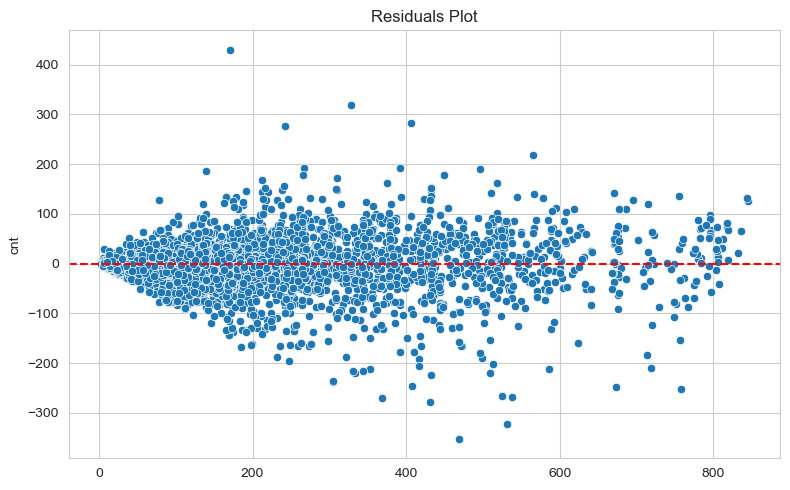

In [28]:
best_model = rf_pipe
best_model.fit(X_train, y_train)
y_pred = best_model.predict(X_test)

residuals = y_test - y_pred

plt.figure(figsize = (8,5))
sns.scatterplot(x=y_pred, y = residuals)
plt.axhline(0, linestyle = '--', c='red')
plt.xlabel = ('Predicted Count')
plt.ylabel = ('Residuals')
plt.title('Residuals Plot')
plt.tight_layout()

To further evaluate the best-performing model, a residual plot was generated using the Random Forest predictions. The residuals appear to be **centered around zero**, indicating that the model does not show strong systematic bias in its predictions.

However, the spread of residuals increases slightly as predicted demand grows, suggesting that the model experiences larger prediction errors during periods of very high demand. This behavior is common in real-world demand forecasting problems where extreme values are more difficult to predict accurately.

### Actual vs Predicted Values

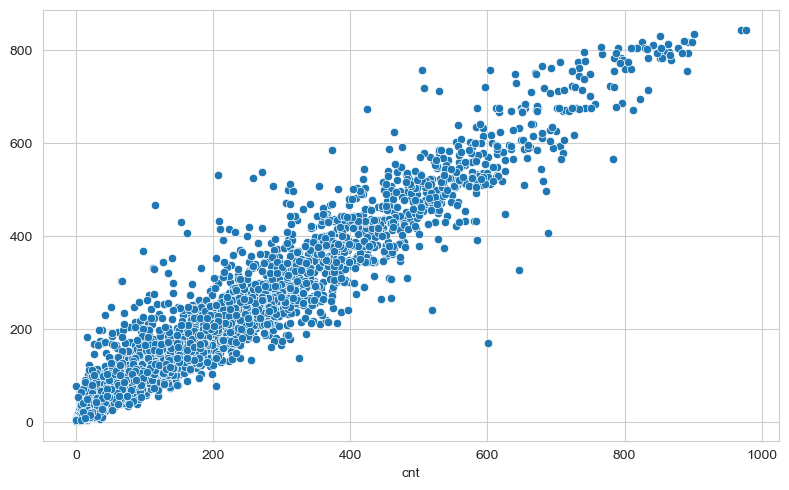

In [29]:
plt.figure(figsize=(8,5))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel = ('Actual Count')
plt.ylabel=("Predicted Count")
plt.title=("Actual vs Predicted")
plt.tight_layout()

The Actual vs Predicted plot shows a strong positive relationship between the predicted and true rental counts. Most points cluster closely around the diagonal trend, indicating that the model is able to capture the overall structure of the data and produce accurate predictions across a wide range of demand levels.

Together, these results indicate that the **Random Forest model provides a strong predictive performance for this dataset and is well-suited for modelling bike rental demand.**

## Feature Importance

To better understand which variables most strongly influence bike rental demand, feature importance scores were extracted from the **Random Forest model**, which was the best-performing model in the comparison.

In [30]:
importances = rf_pipe.named_steps['model'].feature_importances_

features = rf_pipe.named_steps['prep'].get_feature_names_out()

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values("importance", ascending=False)

feat_imp['feature'] = (
    feat_imp['feature']
        .str.replace('num__', '', regex=False)
        .str.replace('cat__', '', regex=False)
        .str.replace('cat_no_onehot__', '', regex=False)
)

print(feat_imp.head(10))

         feature  importance
34        hr_cos    0.318102
33        hr_sin    0.275507
30          temp    0.128494
29            yr    0.091637
28    workingday    0.090229
0       season_1    0.028289
31           hum    0.019704
25  weathersit_3    0.014721
3       season_4    0.007476
32     windspeed    0.004261


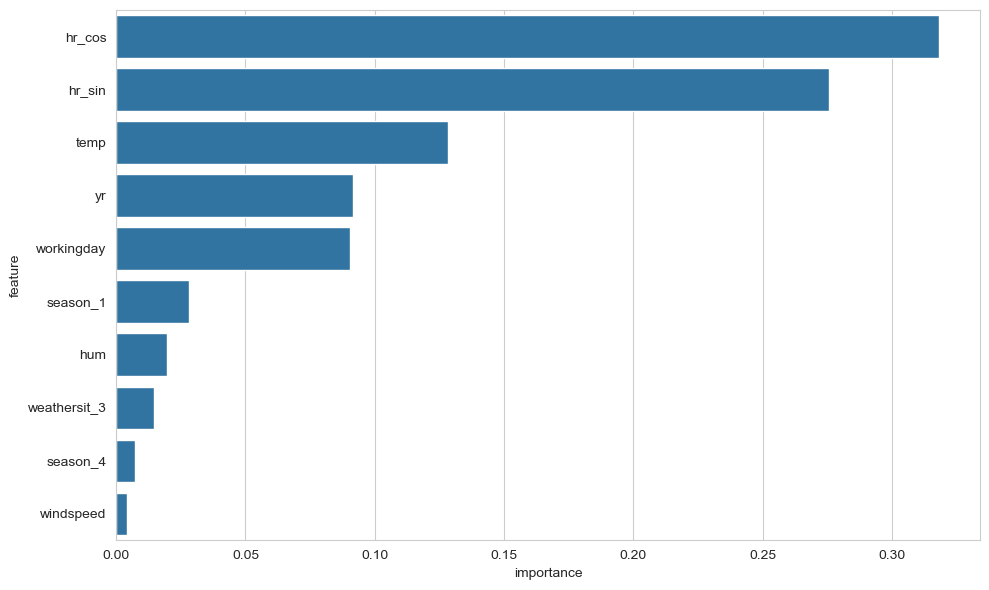

In [33]:
plt.figure(figsize = (10,6))
sns.barplot(data=feat_imp.head(10), x = 'importance', y='feature')
plt.title=('Top 10 Random Forest Feature Importances')
plt.xlabel=('Importance')
plt.ylabel=('Feature')
plt.tight_layout()

plt.savefig("../figures/feature_importance.png", bbox_inches="tight")

plt.show()

The results indicate that **time-related features are the most influential predictors of bike demand**. The cyclical features hr_cos and hr_sin, which represent the hour of the day using sine and cosine transformations, have the highest importance scores. This highlights the strong daily patterns in bike usage, likely driven by commuting behaviour during morning and evening hours.

**Temperature** (temp) is also among the most important features, reinforcing the earlier findings from exploratory analysis that warmer **weather tends to increase bike usage**.

Other variables such as workingday, season, and year contribute moderately to the model’s predictions, suggesting that both seasonal effects and long-term trends influence rental activity. Weather-related variables such as humidity and wind speed appear to have smaller contributions, indicating that while they may affect demand, their impact is less significant compared to time-of-day and temperature patterns.

Overall, the feature importance results confirm that **bike rental demand is primarily driven by daily usage cycles and weather conditions**, with additional influence from seasonal and calendar-related factors.

## Conclusion

In this project, several machine learning models were trained to predict hourly bike rental demand using weather, time, and seasonal features.

Exploratory data analysis revealed clear patterns in bike usage, including strong daily cycles, seasonal variation, and sensitivity to weather conditions. Feature engineering techniques such as cyclical transformations of time variables helped capture these patterns more effectively.

Among the models evaluated, tree-based ensemble methods such as **Random Forest** and **Gradient Boosting** performed significantly better than linear regression, suggesting that the relationship between features and bike demand is **nonlinear**.

Feature importance analysis indicated that time-related variables and weather conditions play a major role in predicting bike rental demand.

Overall, the results demonstrate that ensemble models are highly effective for modeling complex patterns in transportation demand data.